<a href="https://colab.research.google.com/github/asmipandey18/Machine_learning/blob/main/categoricaldata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning for Classification

### Data Preparation
- load the dataset
- look and inspect the dataset
- make column name and values to look uniform
- check if all the columns read correctly
- Check if the churn variable needs any prep

In [283]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [284]:
df = pd.read_csv('/content/archive (4).zip')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [285]:
#@ lets convert the column headers into lowercase

df.columns = df.columns.str.lower().str.replace(' ', '_')

In [286]:
# for each values of categorical data, separating with _

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
categorical_columns

['customerid',
 'gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'totalcharges',
 'churn']

In [287]:
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [288]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


In [289]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [290]:
df.tail().T

,7038,7039,7040,7041,7042
customerid,6840-resvb,2234-xaduh,4801-jzazl,8361-ltmkd,3186-ajiek
gender,male,female,female,male,male
seniorcitizen,0,0,0,1,0
partner,yes,yes,yes,yes,no
dependents,yes,yes,yes,no,no
tenure,24,72,11,4,66
phoneservice,yes,yes,no,yes,yes
multiplelines,yes,yes,no_phone_service,yes,no
internetservice,dsl,fiber_optic,dsl,fiber_optic,fiber_optic
onlinesecurity,yes,no,yes,no,yes


**About Dataset**

- Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

- Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

- The data set includes information about:

- Customers who left within the last month
the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

**Inspiration**

To explore this type of models and learn more about the subject.

In [291]:
df.churn.head()

,churn
0,no
1,no
2,yes
3,no
4,yes


In [292]:
df.churn = (df.churn == 'yes').astype(int)
df.churn.head()

,churn
0,0
1,0
2,1
3,0
4,1


In [293]:
df.shape

(7043, 21)

we have 7043 records, and 21 columns

splitting the dataset

In [294]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [295]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [296]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [297]:
df_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,...,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15,0
1,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,...,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55,0
2,9250-wypll,female,0,no,no,5,yes,yes,fiber_optic,no,...,no,no,no,no,month-to-month,no,electronic_check,75.55,413.65,1
3,6786-obwqr,female,0,yes,yes,5,yes,no,fiber_optic,no,...,no,no,yes,no,month-to-month,yes,electronic_check,80.85,356.1,0
4,1328-euzhc,female,0,yes,no,18,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.10,370.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,1309-xgfsn,male,1,yes,yes,52,yes,yes,dsl,no,...,yes,no,yes,yes,one_year,yes,electronic_check,80.85,4079.55,0
4221,4819-hjpiw,male,0,no,no,18,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,no,mailed_check,25.15,476.8,0
4222,3703-vavcl,male,0,yes,yes,2,yes,no,fiber_optic,no,...,yes,yes,no,yes,month-to-month,no,credit_card_(automatic),90.00,190.05,1
4223,3812-lrzir,female,0,yes,yes,27,yes,yes,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,electronic_check,24.50,761.95,0


In [298]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [299]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [300]:
df_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,yes,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15
1,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,yes,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55
2,9250-wypll,female,0,no,no,5,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,no,electronic_check,75.55,413.65
3,6786-obwqr,female,0,yes,yes,5,yes,no,fiber_optic,no,no,no,no,yes,no,month-to-month,yes,electronic_check,80.85,356.1
4,1328-euzhc,female,0,yes,no,18,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.10,370.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,1309-xgfsn,male,1,yes,yes,52,yes,yes,dsl,no,yes,yes,no,yes,yes,one_year,yes,electronic_check,80.85,4079.55
4221,4819-hjpiw,male,0,no,no,18,no,no_phone_service,dsl,no,no,no,no,no,no,month-to-month,no,mailed_check,25.15,476.8
4222,3703-vavcl,male,0,yes,yes,2,yes,no,fiber_optic,no,no,yes,yes,no,yes,month-to-month,no,credit_card_(automatic),90.00,190.05
4223,3812-lrzir,female,0,yes,yes,27,yes,yes,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,electronic_check,24.50,761.95


### EDA

- Check missing values
- Look at the taeget variable
- Look at numerical and categorical variables

In [301]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,0781-lkxbr,male,1,no,no,9,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,100.50,918.6,1
5192,3507-gasnp,male,0,no,yes,60,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.95,1189.9,0
3980,8868-wozgu,male,0,no,no,28,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,105.70,2979.5,1
235,1251-krreg,male,0,no,no,2,yes,yes,dsl,no,...,no,no,no,no,month-to-month,yes,mailed_check,54.40,114.1,1


In [302]:
df_full_train = df_full_train.reset_index(drop=True)

In [303]:
df_full_train

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0781-lkxbr,male,1,no,no,9,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,100.50,918.6,1
5630,3507-gasnp,male,0,no,yes,60,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.95,1189.9,0
5631,8868-wozgu,male,0,no,no,28,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,105.70,2979.5,1
5632,1251-krreg,male,0,no,no,2,yes,yes,dsl,no,...,no,no,no,no,month-to-month,yes,mailed_check,54.40,114.1,1


In [304]:
df_full_train.isnull().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


In [305]:
df_full_train.churn.value_counts()

,count
churn,
0,4113
1,1521


In [306]:
df_full_train.churn.value_counts(normalize = True) # It gives you the percentage distribution of a variable

,proportion
churn,
0,0.730032
1,0.269968


In [307]:
df_full_train.churn.mean()

np.float64(0.26996805111821087)

In [308]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [309]:
numerical = ['tenure', 'monthly_charges', 'total_charges']


In [310]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod'
]

In [311]:
df_full_train[categorical].nunique()

,0
gender,2
seniorcitizen,2
partner,2
dependents,2
phoneservice,2
multiplelines,3
internetservice,3
onlinesecurity,3
onlinebackup,3
deviceprotection,3


### Feature Importance: Churn rate and risk ratio

- Feature importance means, we need to identify which features affect our target variable

In [312]:
# churn rate per group
# Churn rate per group

global_churn = df_full_train.churn.mean()
print(global_churn)

0.26996805111821087


In [313]:
#@ Looking at individual variables.
# gender

churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()

In [314]:
print(churn_female)

0.27682403433476394


In [315]:
print(churn_male)

0.2632135306553911


In [316]:
global_churn, churn_female, churn_male

(np.float64(0.26996805111821087),
 np.float64(0.27682403433476394),
 np.float64(0.2632135306553911))

In [317]:
global_churn - churn_female

np.float64(-0.006855983216553063)

In [318]:
global_churn - churn_male

np.float64(0.006754520462819769)

Both diff are close to zero, thus, gender is probably not an important feature. It doesnt care about gender

In [319]:
df_full_train.partner.value_counts()

,count
partner,
no,2932
yes,2702


In [320]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()

In [321]:
churn_partner, churn_no_partner

(np.float64(0.20503330866025166), np.float64(0.3298090040927694))



```
# This is formatted as code
```

It looks diff than gender. Customer with parner churn at 20.5%. without parner is 33% and the global is around 27%

In [322]:
global_churn - churn_partner

np.float64(0.06493474245795922)

In [323]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

In [324]:
 # With this defination, gloabl rate minun group rate - postive diff, it means the group churns less than average, and negative diff means it churns more

#### Risk Ratio

The difference is expressed in absolute termns. The same idea can also be expressed in relative terms. As a ratio between the group churn rate and the gloabl churn rate

**1. Difference:**

global churn - group churn


- less than < 0 ; mmore likely to churn

-  greater than > 0 ; less likely to churn


**2. Risk Ratio**

RISK = (GROUP) / (GLOBAL)

If greater > 1: more likely to churn

if lesser <1: less likely to churn

In [325]:
churn_no_partner / global_churn

np.float64(1.2216593879412643)

In [326]:
churn_partner / global_churn

np.float64(0.7594724924338315)

- risk = 1 means the group is as likely to churn as everyone else
- risk >1 means more to churn
- risk < 1 means less likely to churn

**Doing it for every variable with groupby**


In [327]:
for c in categorical:
  print(c)

  df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
  df_group['diff'] = df_group['mean'] - global_churn
  df_group['risk'] = df_group['mean'] / global_churn
  display(df_group)
  print()
  print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


### Feature Importance: Mutual Information
- the churn rate and risk rate tell us which group within one variable churn more, but they dont let us compare whole variables with each other.

- To fix that, we need Mutual Information.

- It is single number per variable that measures how important the feature is

Mutual Information is a concept from  information theory. It tells us how much we can learn about one variable if we know the value of another variable

How much do we learn about churn, if we know the customers's contract type? If knowing a feature algives fives us useful information about churn. The mutual information between them is high and the feature is important. If the feature tells us nothing, the mutual information is 0.

https://thumb.wikimedia.org/wikipedia/commons/thumb/d/d4/Entropy-mutual-information-relative-entropy-relation-diagram.svg/330px-Entropy-mutual-information-relative-entropy-relation-diagram.svg.png?utm_source=en.wikipedia.org&utm_campaign=parser&utm_content=thumbnail



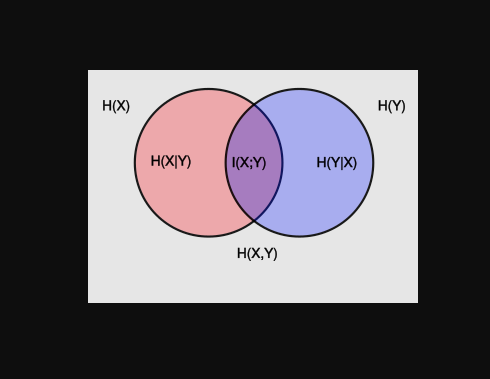

Measuring Cross entropy with Scikit Learn

- we need mutual_info_score

In [328]:
from sklearn.metrics import mutual_info_score
# Let's measure it for a few variables. For contract:

mutual_info_score(df_full_train.churn, df_full_train.contract)

np.float64(0.0983203874041556)

In [329]:
# For gender:

mutual_info_score(df_full_train.gender, df_full_train.churn)

np.float64(0.0001174846211139946)

In [330]:
# And for partner:

mutual_info_score(df_full_train.partner, df_full_train.churn)

np.float64(0.009967689095399745)

The order of the arguments doesn't matter - mutual information is symmetric, so mutual_info_score(df_full_train.contract, df_full_train.churn) gives the same 0.0983.

The numbers confirm what we saw with the risk ratios. Contract has by far the highest score: knowing the contract type teaches us a lot about churn. Gender is almost 0: knowing the gender tells us practically nothing. Partner sits in between.

Applying it to all categorical variables


We could repeat this manually for all 16 variables, but there is a shorter way. mutual_info_score takes two arguments, while pandas apply passes one series at a time - so we wrap it in a function of one argument:

In [331]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

Now we apply it to every categorical column and sort the result from most to least important:



In [332]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

,0
contract,0.098320
onlinesecurity,0.063085
techsupport,0.061032
internetservice,0.055868
onlinebackup,0.046923
deviceprotection,0.043453
paymentmethod,0.043210
streamingtv,0.031853
streamingmovies,0.031581
paperlessbilling,0.017589


The result puts everything on one scale. Contract is the most important categorical variable, followed by onlinesecurity and techsupport - customers without these services churn more, as we saw in the risk ratio tables. At the bottom of the list we find multiplelines, phoneservice and gender - variables that tell us almost nothing about churn.

**Feature importance: Correlation**

Mutual information measures the importance of categorical variables. For numerical variables we use the correlation coefficient instead: it tells us how strongly each numerical feature is related to churn.

**The correlation coefficient**

The correlation coefficient - the Pearson correlation coefficient, usually denoted r - measures the degree of dependency between two variables. It is always a number between -1 and 1:

A value close to 1 means strong positive correlation: when one variable grows, the other grows too.
A value close to -1 means strong negative correlation: when one variable grows, the other decreases.
A value close to 0 means there is no dependency: a change in one variable tells us nothing about the other.
The sign gives the direction of the relationship, and the absolute value gives its strength. One way to interpret the magnitude:

LOW when the absolute value of r is between 0 and 0.2
MEDIUM when it is between 0.2 and 0.5
STRONG when it is between 0.5 and 1.0



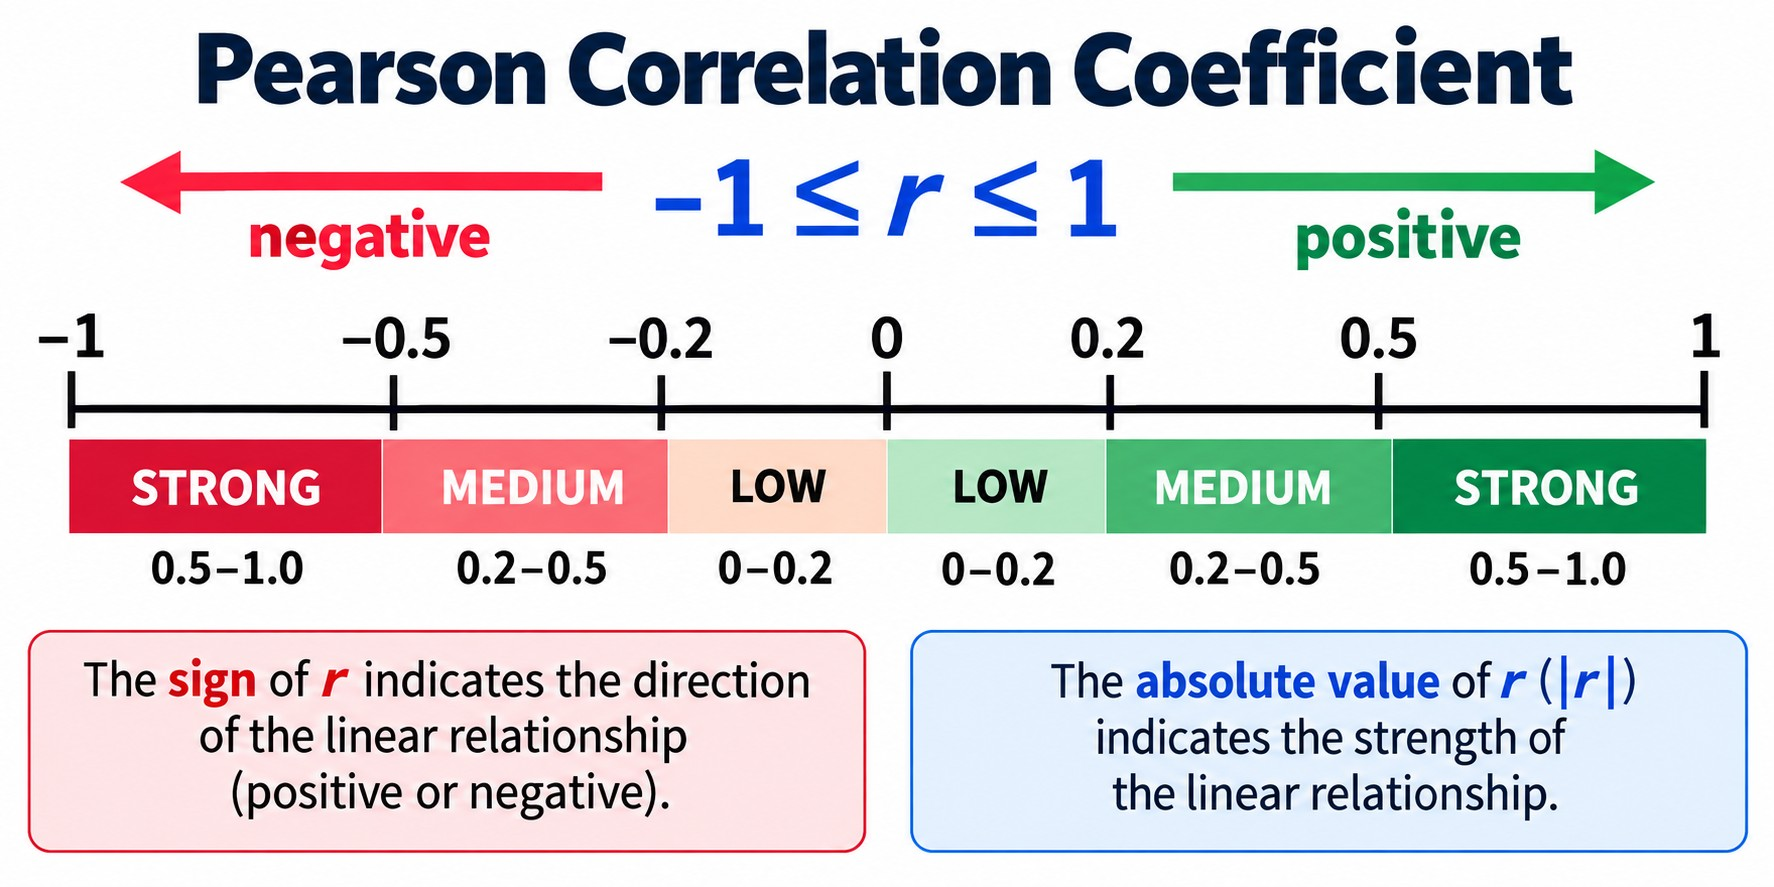


In our case one of the two variables is churn - a binary 0/1 column. If the correlation between a numerical feature and churn is positive, customers with higher values of that feature churn more; if it is negative, they churn less. The larger the absolute value, the more important the feature.

1. Categorical vs. Categorical Data

    When you want to see if two categorical variables (like "Eye Color" and "Hair Color") are related, you use association metrics rather than standard correlation:

      Chi-Square Test of Independence: Tests whether two categorical variables are significantly associated with each other.Cramér’s V: Built on the Chi-Square test, this outputs a value between 0 and 1, indicating the strength of the association (similar to a correlation coefficient).

2. Numerical vs. Categorical DataWhen checking the relationship between a numerical variable (like "Income") and a categorical variable (like "Education Level"):

    ANOVA (Analysis of Variance): Determines if the numerical values significantly differ across the various categories.Point-Biserial Correlation: A specific variation used when the categorical variable is strictly binary (e.g., "Yes" or "No").

3. Numerical vs. Numerical Data
This is where traditional correlation applies:Pearson Correlation: Measures the strength of a linear relationship.Spearman Rank Correlation: Measures monotonic relationships (whether variables increase or decrease together, even if not at a constant linear rate)

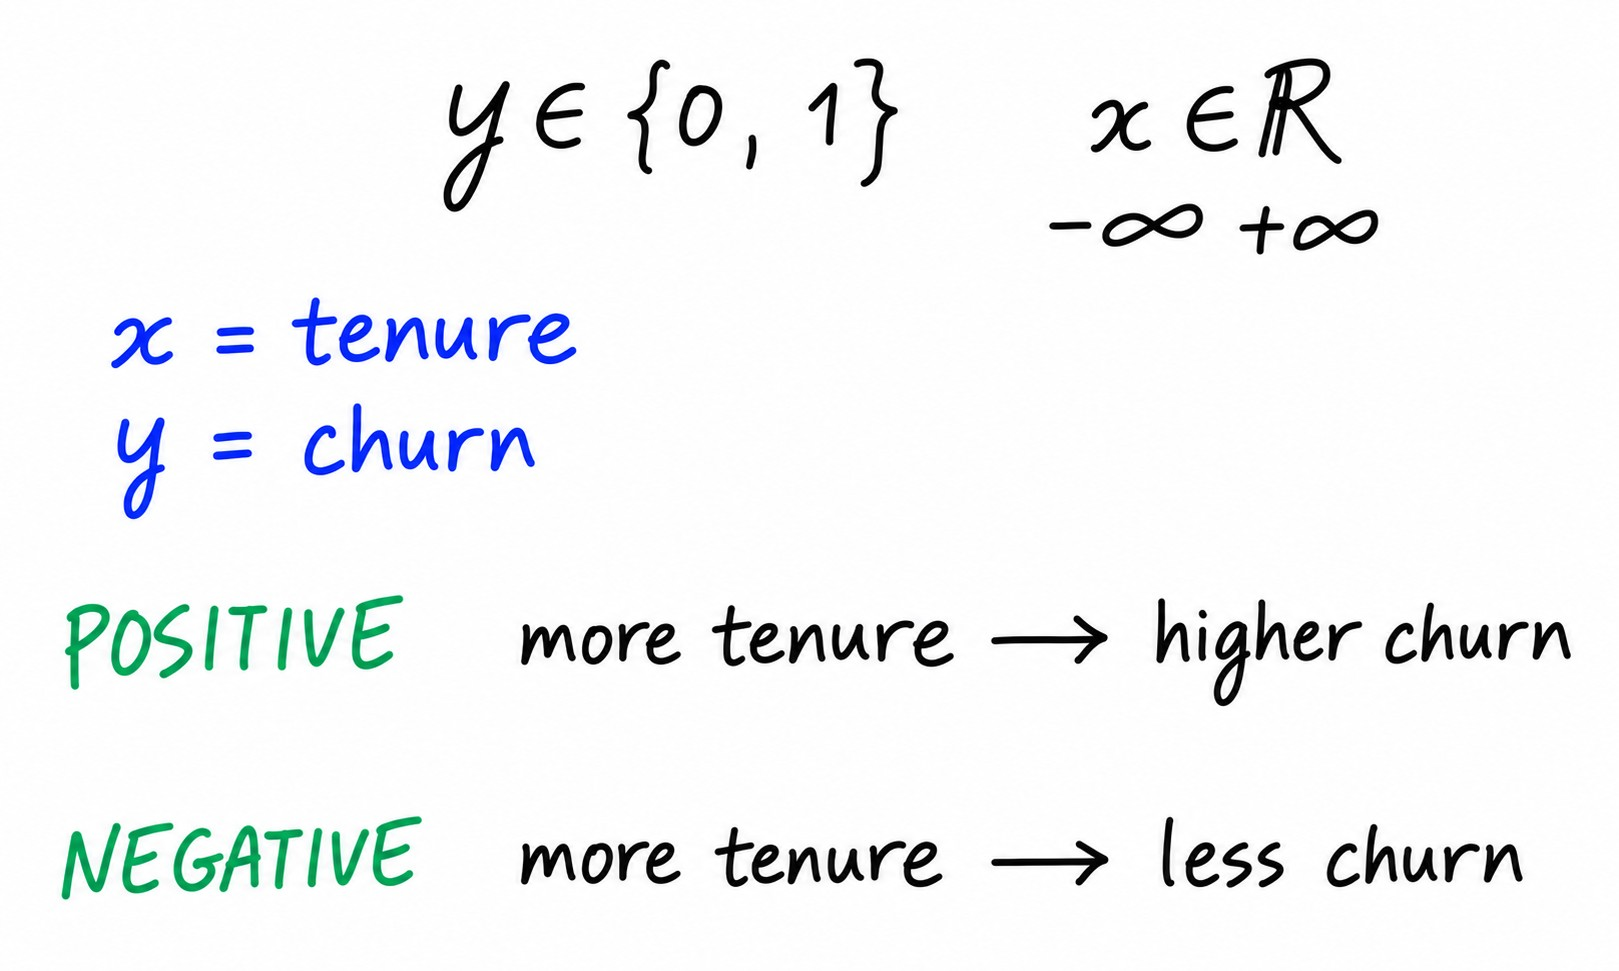

Correlation of numerical features with churn

We have three numerical variables: tenure, monthlycharges and totalcharges. Pandas computes their correlation with the target in one call with corrwith:

In [333]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

# Convert 'totalcharges' to numeric, coercing errors to NaN
# This handles cases where 'totalcharges' might contain non-numeric strings (like '_')
df_full_train['totalcharges'] = pd.to_numeric(df_full_train['totalcharges'], errors='coerce')

# print(df_full_train)

# Fill NaN values (e.g., from original empty strings or now '_') with 0
df_full_train['totalcharges'] = df_full_train['totalcharges'].fillna(0)

df_full_train[numerical].corrwith(df_full_train.churn)



,0
tenure,-0.351885
monthlycharges,0.196805
totalcharges,-0.196353


Let's read this:

- Tenure has a medium negative correlation. The longer customers stay with the company, the less likely they are to churn.
- Monthly charges have a low-to-medium positive correlation: the more customers pay per month, the more likely they are to churn.
- Total charges have a low-to-medium negative correlation - not surprising, since total charges accumulate with tenure.


To rank features by importance we don't care about the direction, only about the strength, so we take the absolute values:

In [334]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

,0
tenure,0.351885
monthlycharges,0.196805
totalcharges,0.196353


Tenure is the most important numerical feature.

Checking the relationship with groups
We can double-check the correlation by splitting customers into groups and computing the churn rate in each - the same idea we used for categorical variables, now applied to bins of a numerical one.

Tenure is measured in months and goes up to 72:

In [335]:
df_full_train.tenure.max()

72

We split it into three groups - two months or less, up to a year, and longer than a year - and look at the churn rate in each:



In [336]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [337]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [338]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

The pattern is striking. Customers who have been with the company for two months or less churn at almost 60%. For customers of up to a year it is about 40%, and for those who stayed longer than a year only about 18%. Churn clearly decreases as tenure grows - exactly what the negative correlation told us.

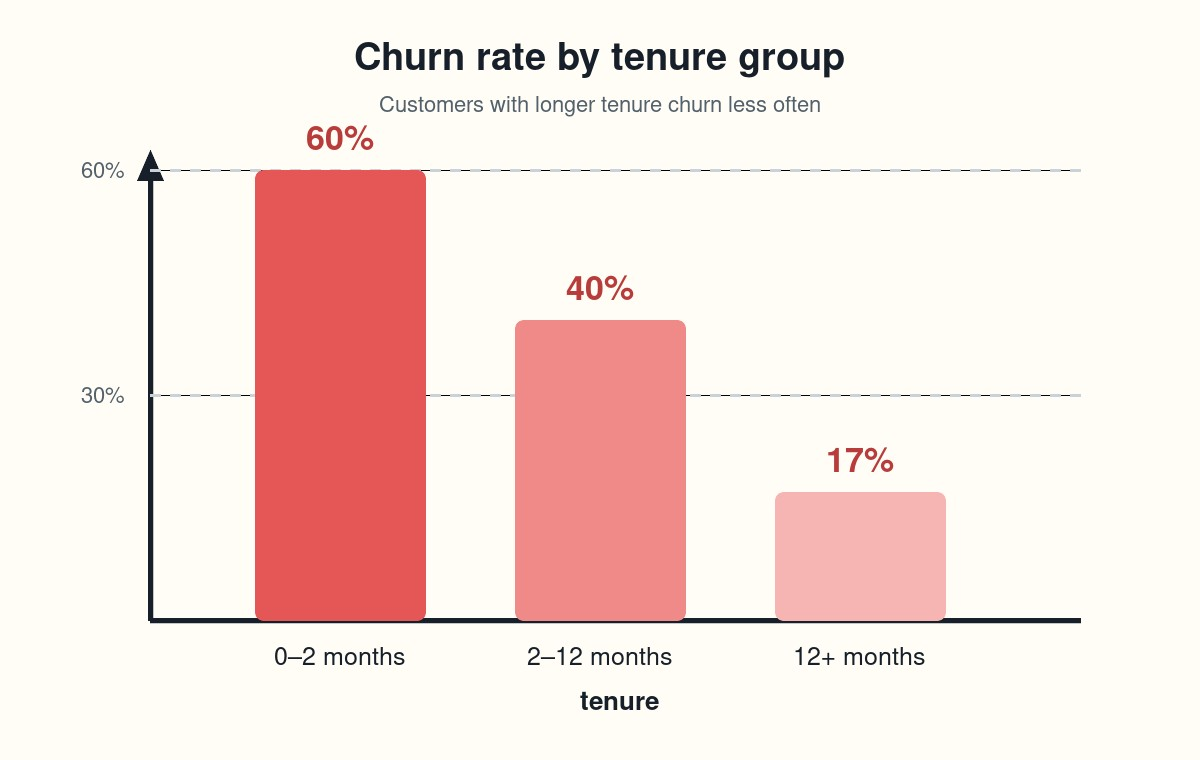

The same check for monthly charges:



In [339]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [340]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [341]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

Here the relationship goes the other way: customers paying at most $20 churn at about 9%, and customers paying more than $50 churn at about 32%. The more people pay monthly, the more likely they are to leave - the positive correlation confirmed.



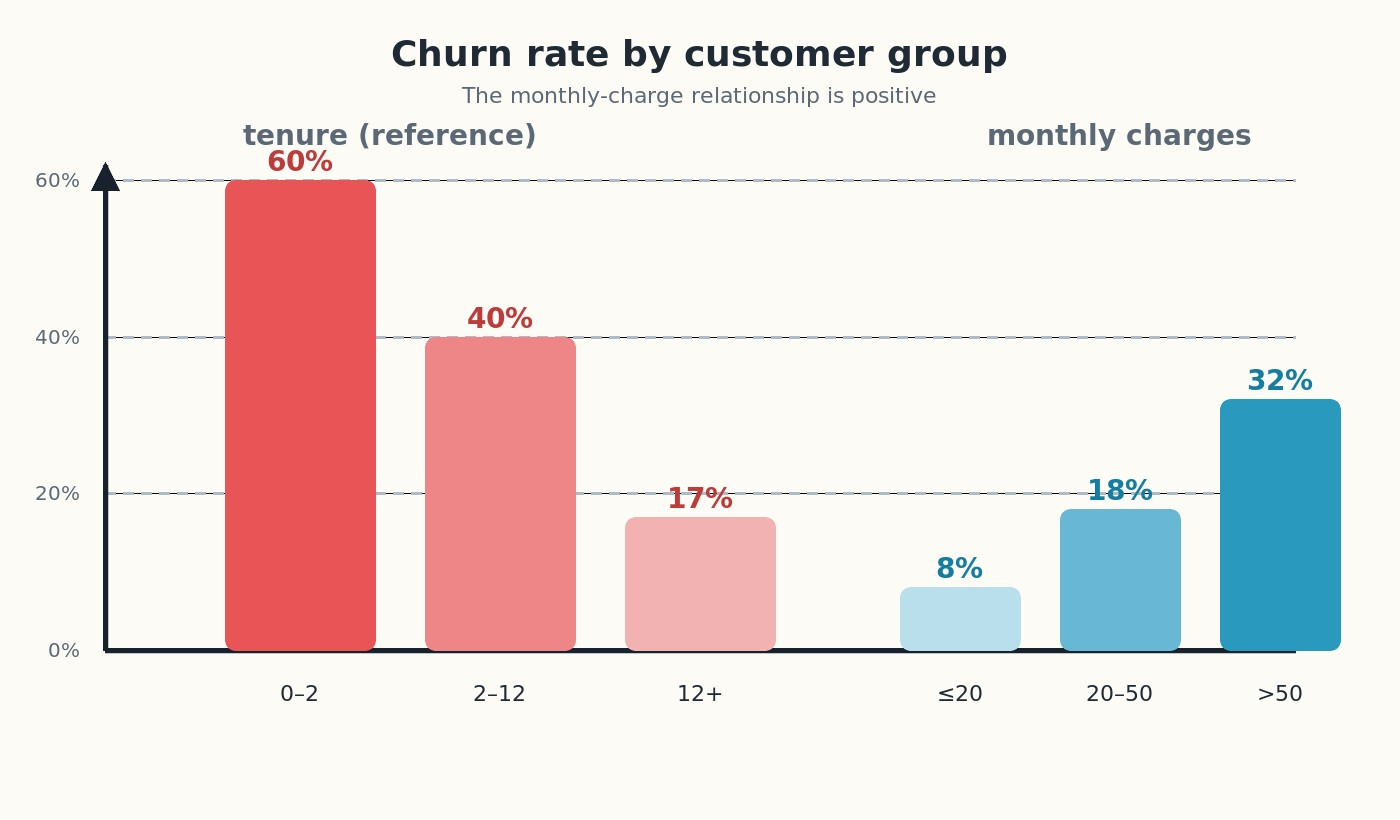

We now know the importance of categorical variables (mutual information) and numerical variables (correlation). Next we prepare the categorical variables for the model with one-hot encoding.

One Hot Encoding

- ML model works with numbers
- OHE replaces one categorical column into several binary columns.- one per category.

- we need to implement OHE for categorical data

In [342]:
#@ Implement Scikit learn to encode categorical features

DictVectorizer takes a list of dict, one dict per row, we convert a datagrame to this format with pandas

In [343]:
from sklearn.feature_extraction import DictVectorizer

In [344]:
dv = DictVectorizer(sparse = False)

In [345]:
train_dict = df_train[categorical + numerical].to_dict(orient = 'records')

In [346]:
df_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,8015-ihcgw,female,0,yes,yes,72,yes,yes,fiber_optic,yes,yes,yes,yes,yes,yes,two_year,yes,electronic_check,115.50,8425.15
1,1960-uycnn,male,0,no,no,10,yes,yes,fiber_optic,no,yes,yes,no,no,yes,month-to-month,yes,electronic_check,95.25,1021.55
2,9250-wypll,female,0,no,no,5,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,no,electronic_check,75.55,413.65
3,6786-obwqr,female,0,yes,yes,5,yes,no,fiber_optic,no,no,no,no,yes,no,month-to-month,yes,electronic_check,80.85,356.1
4,1328-euzhc,female,0,yes,no,18,yes,no,no,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,20.10,370.5


In [347]:
X_train = dv.fit_transform(train_dict)

In [348]:
val_dict = df_val[categorical + numerical].to_dict(orient = 'records')

In [349]:
X_val = dv.transform(val_dict)

In [350]:
X_train.shape

(4225, 4056)

So far we are ready for model training part..

- we are still at classification .

- We will apply for Binary Classification
- Linear vs Logistics regression

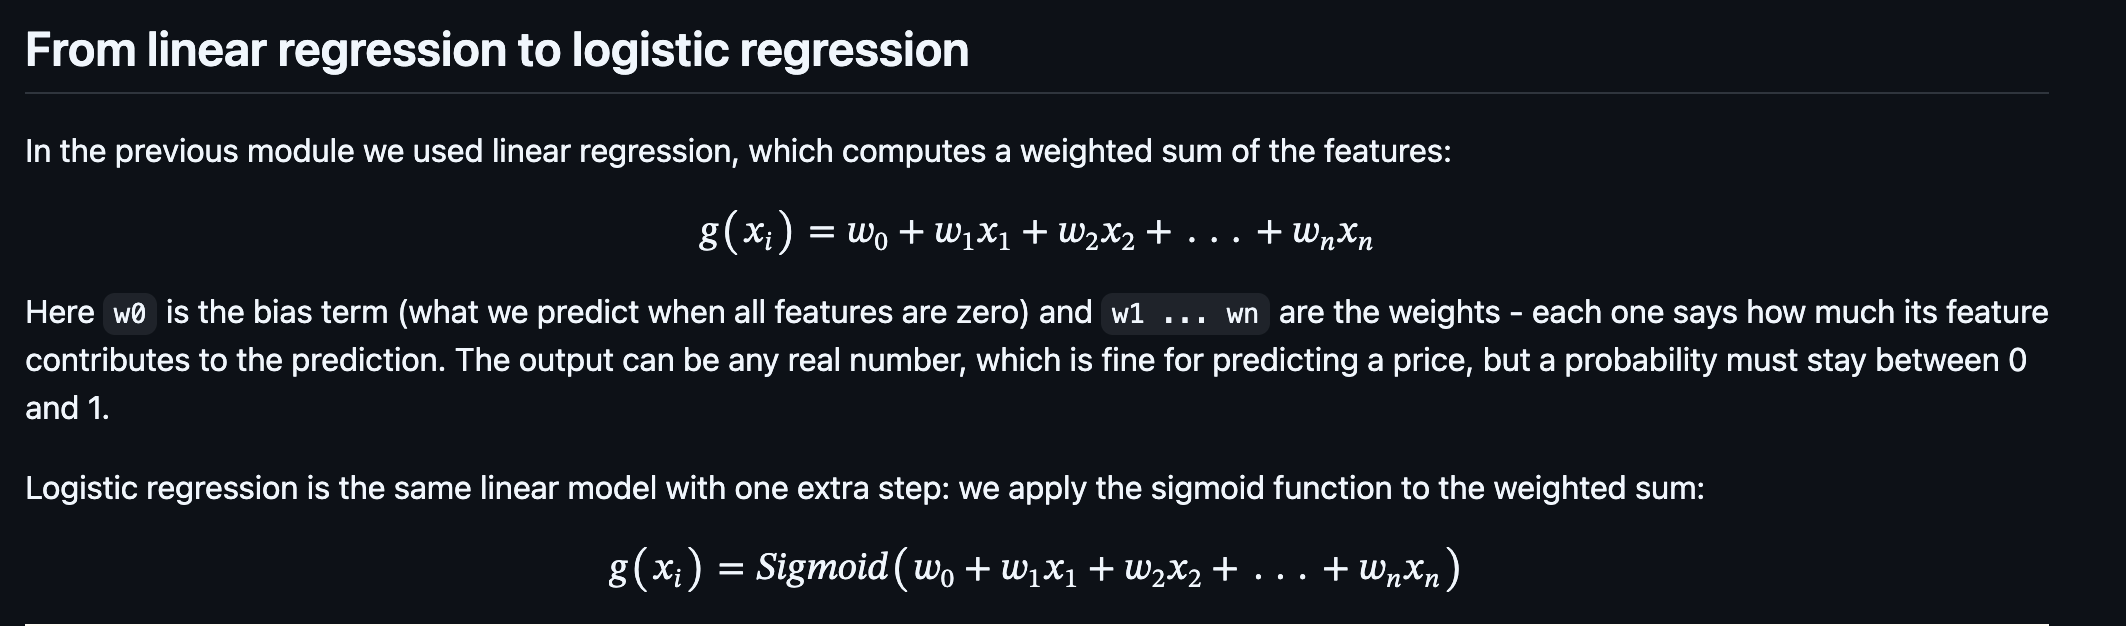

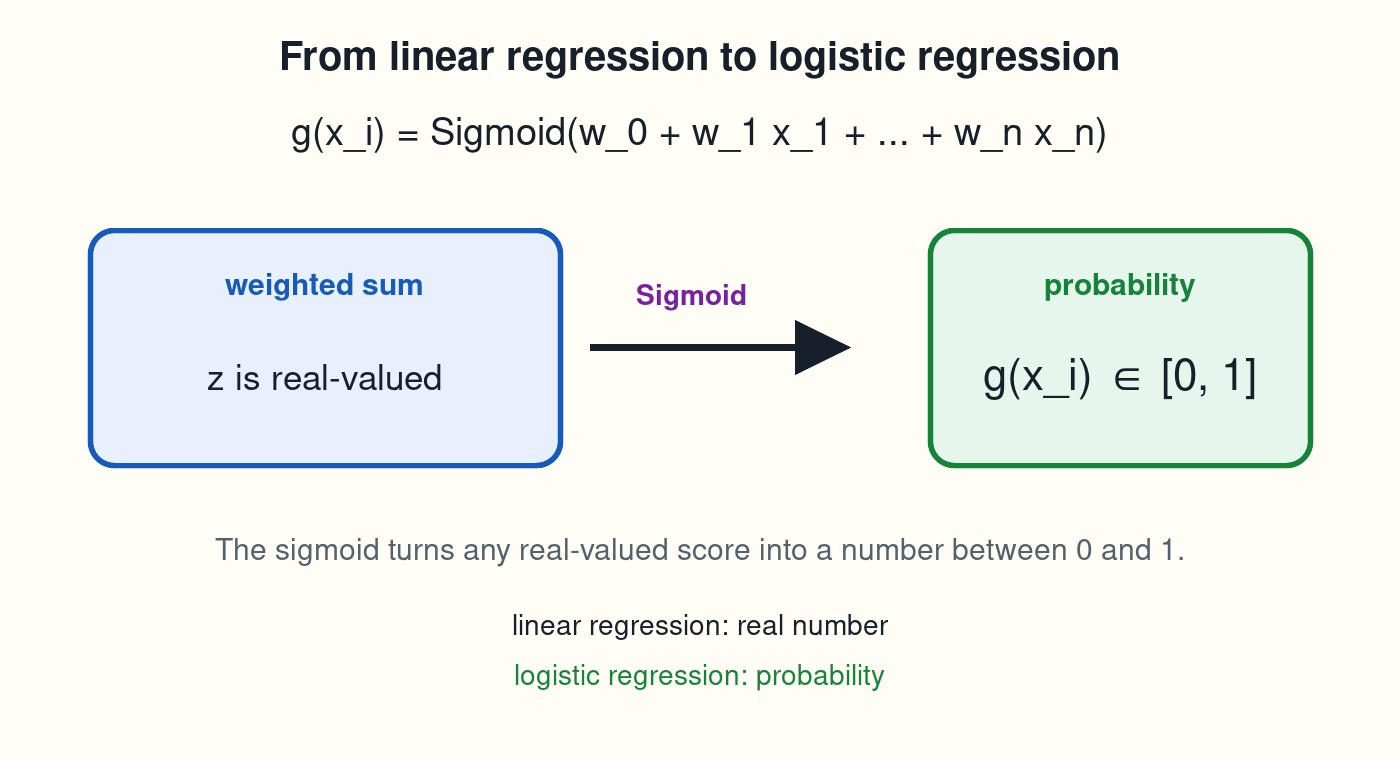

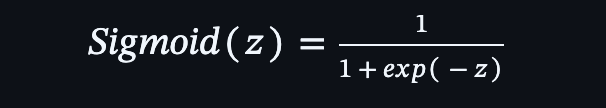

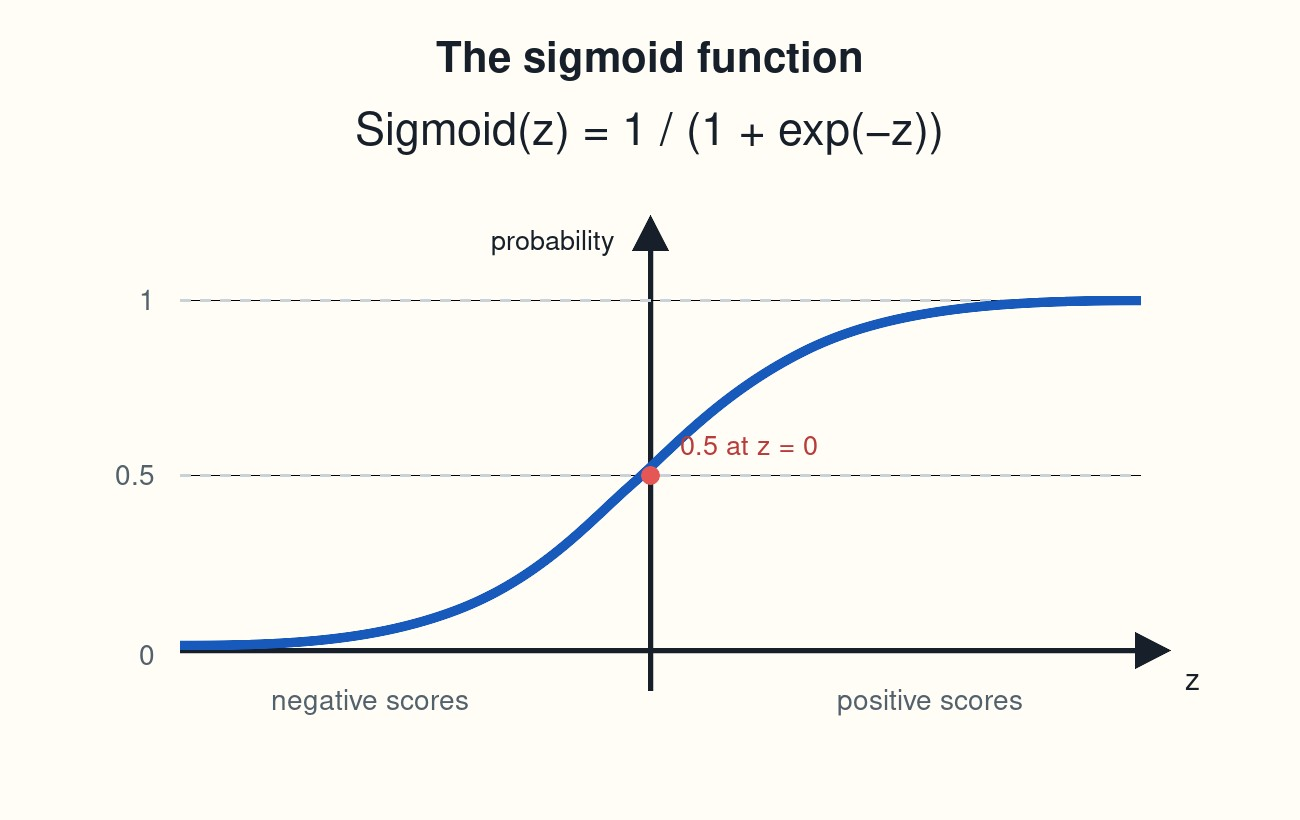

In [351]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [352]:
sigmoid(10)

np.float64(0.9999546021312976)

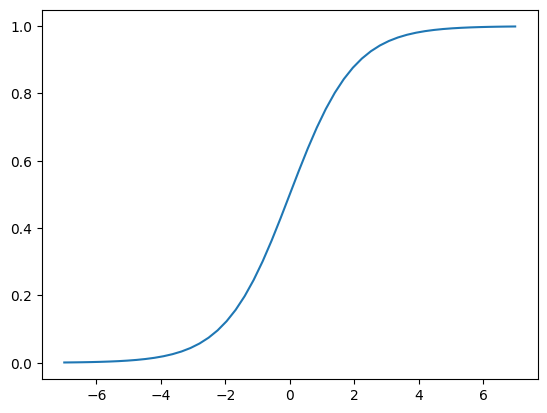

In [353]:
#@ if i try to plot the behaviour of sigmoid function

z = np.linspace(-7, 7, 51)
plt.plot(z, sigmoid(z))

Implementing the models

In [354]:
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j] * w[j]

    return result

In [355]:
#@ Logistic regression needs only one change i.e you need to pass the score through the sigmoid before returning it

def logistic_regression(xi):
    score = w0

    for j in range(len(w)):
        score = score + xi[j] * w[j]

    result = sigmoid(score)
    return result

## Logistic Regression with Scikit-Learn

**steps**
- model import
- model fit
- model evaluate


In [356]:
from sklearn.linear_model import LogisticRegression

In [357]:
model = LogisticRegression(solver = 'lbfgs')
#solver = 'lbfgs' is the default solver in newer version of sklearn

# for other version, you need to specify


In [358]:
X_train, y_train

(array([[0., 0., 1., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]]),
 array([0, 0, 1, ..., 1, 0, 1]))

In [359]:
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [360]:
#the bias term: w0

model.intercept_[0]

np.float64(-0.19582069514346345)

In [361]:
#@ The weights are in coef_
model.coef_[0].round(3)

array([ 0.881,  0.131, -1.194, ...,  0.031, -0.047, -0.075])

Making predictions

we have two methods
- model.predict(X)
- model.predict_proba(X)

In [362]:
y_pred = model.predict_proba(X_val)

In [363]:
y_pred

array([[0.9946884 , 0.0053116 ],
       [0.77583118, 0.22416882],
       [0.78263621, 0.21736379],
       ...,
       [0.87671435, 0.12328565],
       [0.16924293, 0.83075707],
       [0.15352179, 0.84647821]])

In [364]:
# predict_proba returns a matrix with two columns: the probability of class 0 and the probability of class 1. the two columns always sum up to 1. so it is enough to take the second one.
y_pred = model.predict_proba(X_val)[:, 1]

In [365]:
y_pred

array([0.0053116 , 0.22416882, 0.21736379, ..., 0.12328565, 0.83075707,
       0.84647821])

In [366]:
#@ We now decide if the model think the probability of churn is 50% or more, then we predict that the customer will churn

churn_decision = (y_pred >= 0.5)

In [367]:
churn_decision

array([False, False, False, ..., False,  True,  True])

## Accuracy
measures the overall proportion of correct predictions made by the model out of all total predictions.

In [368]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [369]:
y_val

array([0, 0, 0, ..., 0, 1, 1])

In [370]:
#@ We can also look at it from the dataframe.
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val
df_pred.head(10)

,probability,prediction,actual
0,0.005312,0,0
1,0.224169,0,0
2,0.217364,0,0
3,0.576315,1,1
4,0.212274,0,0
5,0.228391,0,0
6,0.036869,0,0
7,0.006132,0,0
8,0.669283,1,1
9,0.401126,0,1


Actual x Prediction

- a1 = apple = 0.55
- a2 = apple = 0.60
- a3 = ball = 0.58
- a4 = apple = 0.66
- a5 = apple = 0.78

accuracy = 4/5 = 80%

if th > 60%

accuracy = 3/5 = 60%


We calculate model accuracy in

---

validation set.

In [371]:
len(y_val)

1409

In [372]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [373]:
# 0.7764371894960965 = X / 1409
1409 * 0.7764371894960965

1094.0

In [374]:
#@ It shows out of 1409 validation data, 1094 data were correctly classified


In [375]:
from sklearn.metrics import accuracy_score
accuracy_score(y_val, y_pred >= 0.5)

0.8034066713981547

If we check with different threshold values:
- the 0.5 threshold was a random guess, Nothing forces us to use it.
- the model outputs a probability, and we can annouce churn for any cutoff we like.
- lets check all threshold from 0 to 1 in steps of 0.05 and see which one gives the best accuracy

0.000000 0.274
0.050000 0.534
0.100000 0.603
0.150000 0.644
0.200000 0.696
0.250000 0.730
0.300000 0.759
0.350000 0.771
0.400000 0.786
0.450000 0.801
0.500000 0.803
0.550000 0.806
0.600000 0.801
0.650000 0.793
0.700000 0.774
0.750000 0.747
0.800000 0.738
0.850000 0.727
0.900000 0.726
0.950000 0.726
1.000000 0.726


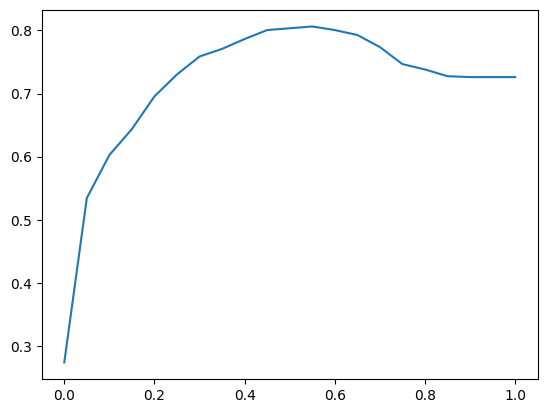

In [376]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
  score = accuracy_score(y_val, y_pred >= t)
  print('%2f %.3f' % (t, score))
  scores.append(score)

plt.plot(thresholds, scores)

### Confusion Matrix

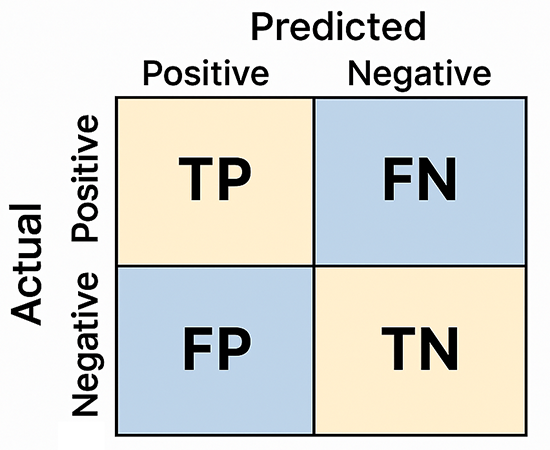

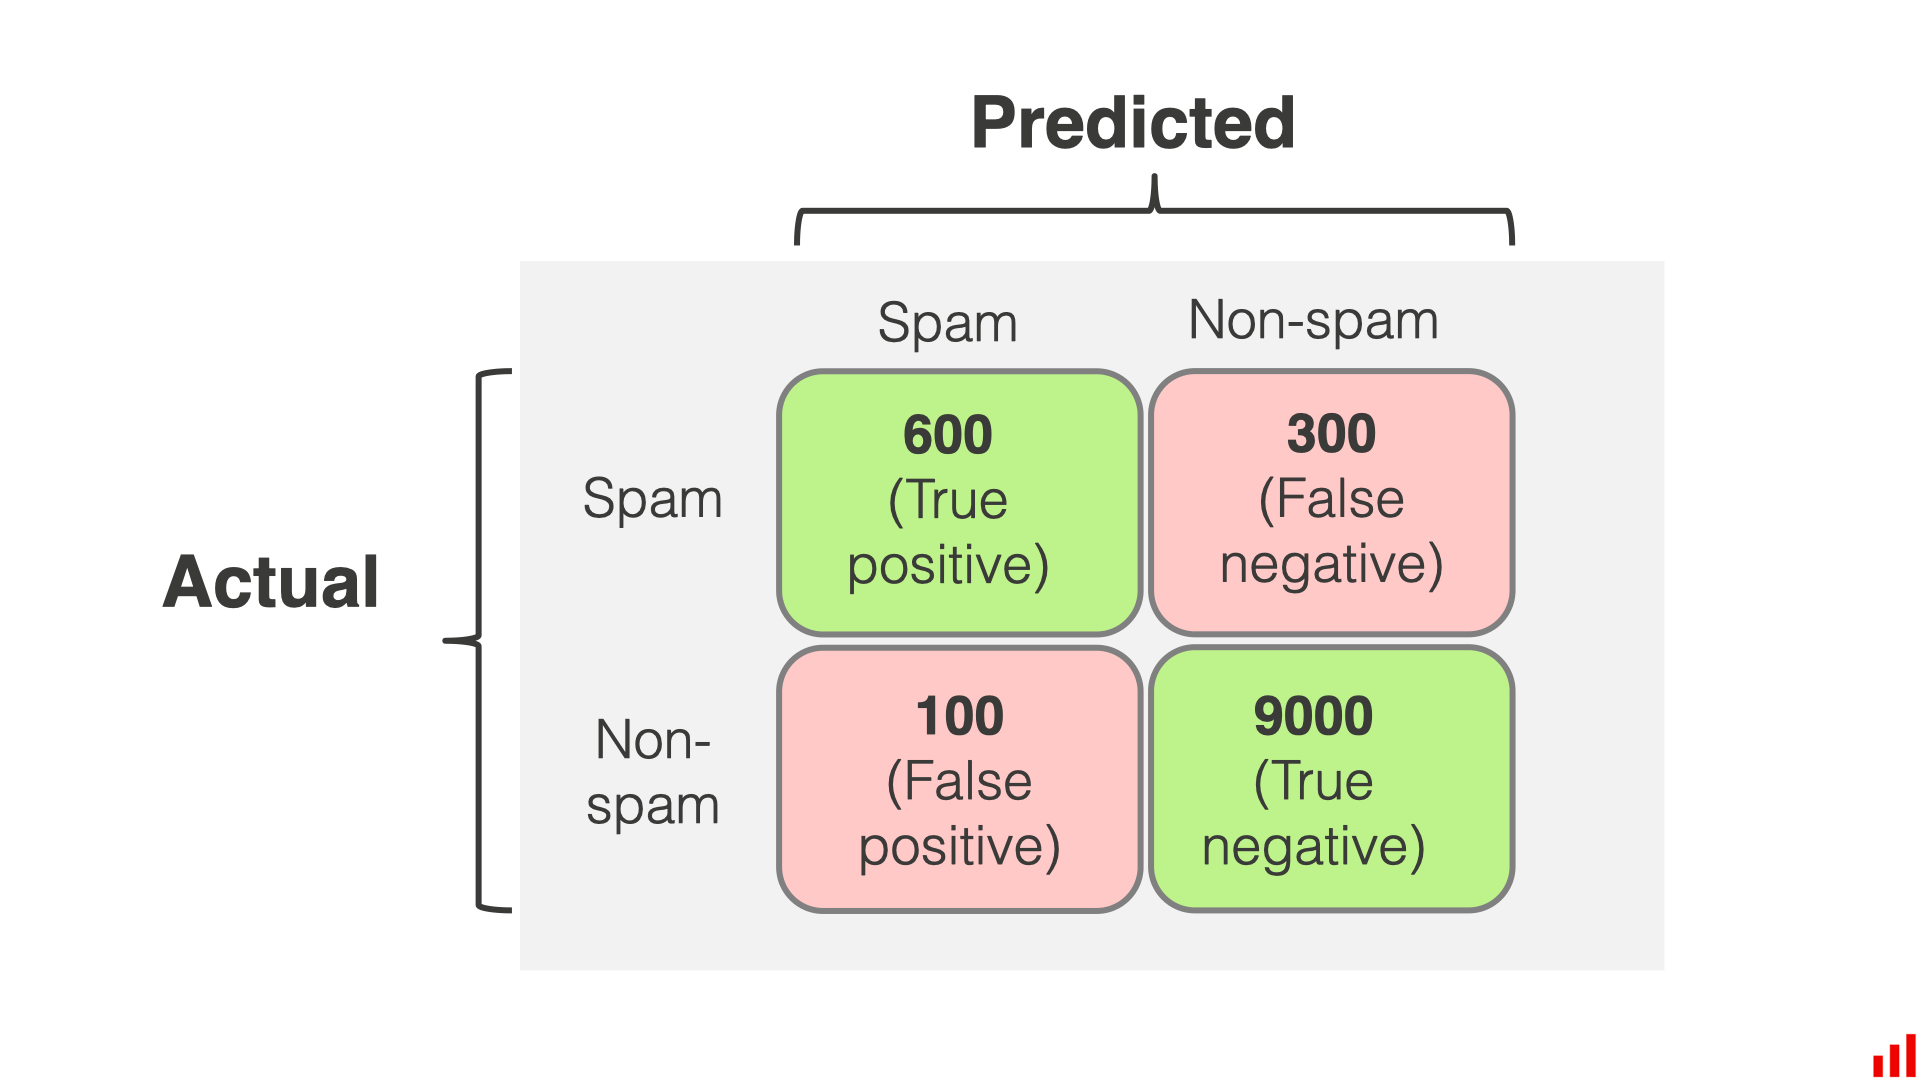

Total testing points: 10,000

out to 10k emails,

- 600 emails were actually spam and model also predicted as spam
- 300 emails were actually spam but model predicted as non spam
- 100 emails were non spam but model predicted as spam
- 9000 emails were non spam and model also predicted as non spam


- Precision:

        p = TP / (TP + FP)

        = 600 / (600 + 100)

  Model le total predict gareko 700 ho! yo madde correctly predict gareko chai 600 matra ho. So, kati fraction le actual ma correctly predict garirakhya cha, thats what we call it as a precision score. Interview question



In [377]:
600/700

0.8571428571428571

- Recall: TP / (TP + FN)


Modle le perfectly predict gareko, chahe tyo spam hos or non spam class hos:

600 + 9000

yo madde bata, positive class ko fraction out of perfectly predicted numbers chahe tyo positive hos or negative hos, eslai nai hami vancham

recall

In [378]:
r = 600/(600+9000)

In [379]:
r

0.0625